# MGMA Project Part 2

### Methods Implemented:
1. **Spectral Clustering** (Laplacian Eigenmaps)
   - Unnormalized Laplacian
   - Symmetric Normalized Laplacian  
   - Random Walk Laplacian
   
2. **Node2Vec** 
   - With different p, q parameters for BFS/DFS trade-off
   - Manual implementation; libraries can be used for comparison

3. **GNN (GCN) for community detection** (Part 6)
   - 2-layer GCN, unsupervised reconstruction loss, k-means on embeddings

4. **Link prediction with GCN** (Part 7 & 8)
   - Richer node features: degree, clustering coefficient, PageRank
   - 2-layer GCN encoder + MLP decoder on $[z_u \| z_v]$
   - BCE loss, train/val/test split (RandomLinkSplit), early stopping
   - Tested on Facebook graph (Part 7) and Email-Eu-core (Part 8)

### Comparison with Existing Methods (community detection):
- Louvain
- Label Propagation (LPA)
- Walktrap

### Evaluation Metrics:
- **Community detection:** Modularity, Coverage, Conductance, ARI, NMI, Runtime
- **Link prediction:** AUC-ROC, Average Precision, Accuracy, MRR, HITS@1/3/10/50

In [87]:
# Import libraries
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from collections import Counter, defaultdict
import time
import warnings
from gensim.models import Word2Vec
import pandas as pd
import community.community_louvain as community_louvain
import igraph as ig

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [88]:
# Load Facebook dataset
txt_file = 'data/facebook_combined.txt'
G_fb = nx.read_edgelist(txt_file, create_using=nx.Graph(), nodetype=int)

print(f"Facebook Network Loaded:")
print(f"  Nodes: {G_fb.number_of_nodes()}")
print(f"  Edges: {G_fb.number_of_edges()}")
print(f"  Density: {nx.density(G_fb):.4f}")
print(f"  Connected: {nx.is_connected(G_fb)}")

Facebook Network Loaded:
  Nodes: 4039
  Edges: 88234
  Density: 0.0108
  Connected: True


## Part 1: Spectral Clustering (Laplacian Eigenmaps)

- **Laplacian Matrix**: L = D - A
- **Key Property**: Eigenvalues reveal community structure 
- **Eigengap Heuristic**: Maximum gap between eigenvalues suggests optimal k
- **Algorithm** 
  1. Compute k smallest eigenvectors
  2. Form embedding matrix U
  3. Run k-means on embeddings

In [6]:
class SpectralClustering:
    """
    Spectral Clustering using different Laplacian variants
    Based on slides pages 4-12
    """
    
    def __init__(self, graph, n_clusters):
        self.G = graph
        self.n_clusters = n_clusters
        self.n_nodes = len(graph.nodes())
        self.nodes = list(graph.nodes())
        self.node_to_idx = {node: idx for idx, node in enumerate(self.nodes)}
        
    def compute_laplacian(self, laplacian_type='unnormalized'):
        """Compute Laplacian matrix (Slide 4, 6)"""
        A = nx.adjacency_matrix(self.G, nodelist=self.nodes).astype(float)
        degrees = np.array(A.sum(axis=1)).flatten()
        D = np.diag(degrees)
        
        if laplacian_type == 'unnormalized':
            L = D - A.toarray()  # L = D - A
        elif laplacian_type == 'symmetric':
            D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degrees, 1e-10)))
            L_unnorm = D - A.toarray()
            L = D_inv_sqrt @ L_unnorm @ D_inv_sqrt  # L_sym = D^(-1/2) L D^(-1/2)
        elif laplacian_type == 'random_walk':
            D_inv = np.diag(1.0 / np.maximum(degrees, 1e-10))
            L_unnorm = D - A.toarray()
            L = D_inv @ L_unnorm  # L_rw = D^(-1) L
        else:
            raise ValueError(f"Unknown laplacian type: {laplacian_type}")
        
        return L
    
    def find_optimal_k_eigengap(self, L, max_k=20):
        """Use eigengap heuristic to find optimal k (Slide 8)"""
        eigenvalues = np.linalg.eigvalsh(L)
        eigenvalues = np.sort(eigenvalues)[:max_k+1]
        eigengaps = np.diff(eigenvalues)
        optimal_k = np.argmax(eigengaps[1:]) + 2  # Skip first gap
        return optimal_k, eigenvalues, eigengaps
    
    def fit_predict(self, laplacian_type='unnormalized'):
        """Perform spectral clustering (Slide 9)"""
        print(f"  Running Spectral Clustering with {laplacian_type} Laplacian...")
        
        # Compute Laplacian
        L = self.compute_laplacian(laplacian_type)
        
        # Find k smallest eigenvectors
        k = self.n_clusters
        n_eigs = k + 1 if laplacian_type == 'unnormalized' else k
        eigenvalues, eigenvectors = eigh(L, subset_by_index=[0, n_eigs-1])
        
        # Form embedding matrix U (Slide 9)
        if laplacian_type == 'unnormalized':
            U = eigenvectors[:, 1:k+1]  # Skip first eigenvector
        else:
            U = eigenvectors[:, :k]
        
        # Normalize rows
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        row_norms[row_norms == 0] = 1
        U_normalized = U / row_norms
        
        # K-means clustering
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(U_normalized)
        
        # Create community dictionary
        communities = {node: int(labels[self.node_to_idx[node]]) 
                      for node in self.nodes}
        
        return communities, U, eigenvalues

Analyzing Eigenvalue Spectrum...



Eigengap heuristic suggests: k = 7 communities

First 10 eigenvalues: [-1.69071397e-14  1.81476475e-02  2.89880334e-02  4.71877971e-02
  6.82694270e-02  1.10552609e-01  1.63108263e-01  6.78447047e-01
  7.33054089e-01  9.12503550e-01]
First 10 eigengaps: [0.01814765 0.01084039 0.01819976 0.02108163 0.04228318 0.05255565
 0.51533878 0.05460704 0.17944946 0.08749645]


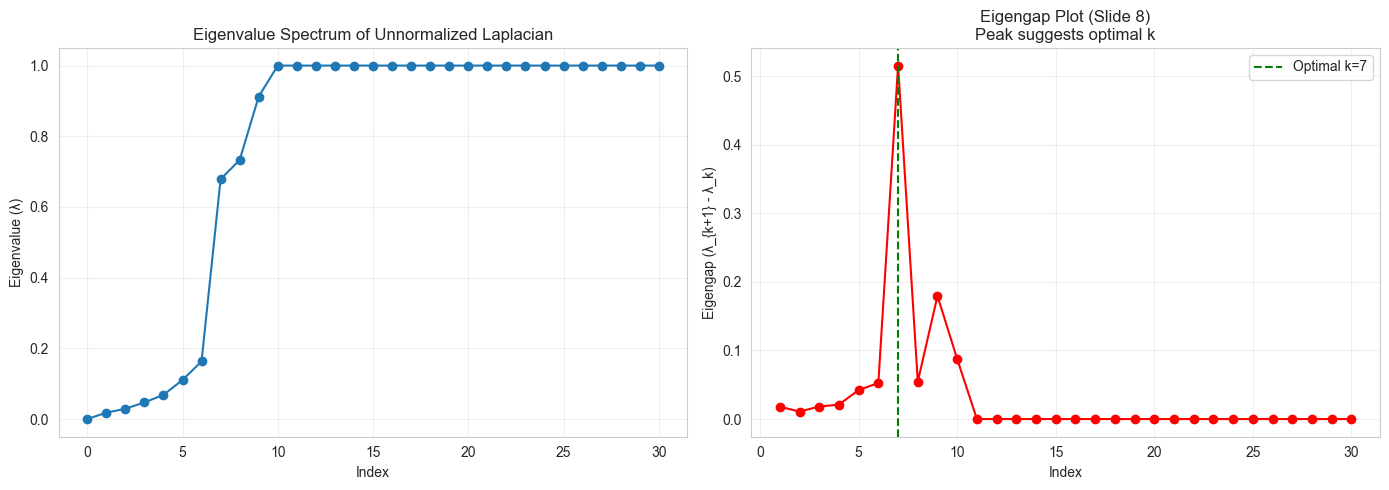


→ We'll use k = 7 for spectral methods


In [7]:
# Analyze eigenvalue spectrum to determine optimal k
print("Analyzing Eigenvalue Spectrum...\n")

# Test with unnormalized Laplacian
spectral_test = SpectralClustering(G_fb, n_clusters=10)
L = spectral_test.compute_laplacian('unnormalized')
k_opt, eigenvalues, eigengaps = spectral_test.find_optimal_k_eigengap(L, max_k=30)

print(f"Eigengap heuristic suggests: k = {k_opt} communities")
print(f"\nFirst 10 eigenvalues: {eigenvalues[:10]}")
print(f"First 10 eigengaps: {eigengaps[:10]}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(len(eigenvalues)), eigenvalues, 'o-', markersize=6)
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue (λ)')
ax1.set_title('Eigenvalue Spectrum of Unnormalized Laplacian')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(eigengaps)+1), eigengaps, 'o-', markersize=6, color='red')
ax2.set_xlabel('Index')
ax2.set_ylabel('Eigengap (λ_{k+1} - λ_k)')
ax2.set_title('Eigengap Plot (Slide 8)\nPeak suggests optimal k')
ax2.axvline(k_opt, color='green', linestyle='--', label=f'Optimal k={k_opt}')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n→ We'll use k = {k_opt} for spectral methods")

In [8]:
# Run Spectral Clustering with different Laplacian types
spectral_results = {}

print("Running Spectral Clustering Methods...\n")
print("="*70)

for lap_type in ['unnormalized', 'symmetric', 'random_walk']:
    print(f"\n{lap_type.upper()} LAPLACIAN")
    print("-"*70)
    
    spectral = SpectralClustering(G_fb, n_clusters=k_opt)
    
    start_time = time.time()
    communities, embeddings, eigenvalues = spectral.fit_predict(lap_type)
    elapsed = time.time() - start_time
    
    spectral_results[f'spectral_{lap_type}'] = {
        'communities': communities,
        'embeddings': embeddings,
        'runtime': elapsed,
        'eigenvalues': eigenvalues
    }
    
    print(f"  ✓ Completed in {elapsed:.2f}s")
    print(f"  Communities detected: {len(set(communities.values()))}")

print("\n" + "="*70)
print("Spectral methods completed!")

Running Spectral Clustering Methods...


UNNORMALIZED LAPLACIAN
----------------------------------------------------------------------
  Running Spectral Clustering with unnormalized Laplacian...


  ✓ Completed in 16.48s
  Communities detected: 7

SYMMETRIC LAPLACIAN
----------------------------------------------------------------------
  Running Spectral Clustering with symmetric Laplacian...
  ✓ Completed in 19.42s
  Communities detected: 7

RANDOM_WALK LAPLACIAN
----------------------------------------------------------------------
  Running Spectral Clustering with random_walk Laplacian...
  ✓ Completed in 13.03s
  Communities detected: 7

Spectral methods completed!


## Part 2: Node2Vec Community Detection

- **Random Walks**: Sample neighborhoods through biased walks
- **Parameters**:
  - **p** (return parameter): Controls likelihood of returning to previous node
  - **q** (in-out parameter): Controls exploration vs. exploitation
    - Small q → explore far (DFS-like)
    - Large q → stay local (BFS-like)
- **Pipeline**:
  1. Generate random walks
  2. Train Word2Vec Skip-gram
  3. Extract embeddings
  4. Cluster with k-means

In [9]:
class Node2VecCommunityDetection:
    """
    Node2Vec-based community detection
    Based on slides pages 19-27
    """
    
    def __init__(self, graph, n_clusters, dimensions=64, walk_length=30,
                 num_walks=200, p=1.0, q=1.0, window=10, workers=4):
        self.G = graph
        self.n_clusters = n_clusters
        self.dimensions = dimensions
        self.walk_length = walk_length
        self.num_walks = num_walks
        self.p = p  # Return parameter
        self.q = q  # In-out parameter
        self.window = window
        self.workers = workers
        self.nodes = list(graph.nodes())
        
    def node2vec_walk(self, start_node):
        """Generate biased random walk (Slide 26)"""
        walk = [start_node]
        
        while len(walk) < self.walk_length:
            cur = walk[-1]
            neighbors = list(self.G.neighbors(cur))
            
            if len(neighbors) == 0:
                break
                
            if len(walk) == 1:
                walk.append(np.random.choice(neighbors))
            else:
                prev = walk[-2]
                # Compute biased probabilities (Slide 26)
                probs = []
                for neighbor in neighbors:
                    if neighbor == prev:
                        probs.append(1.0 / self.p)  # Return
                    elif self.G.has_edge(neighbor, prev):
                        probs.append(1.0)  # Stay in neighborhood
                    else:
                        probs.append(1.0 / self.q)  # Move outward
                
                probs = np.array(probs)
                probs = probs / probs.sum()
                walk.append(np.random.choice(neighbors, p=probs))
        
        return walk
    
    def generate_walks(self):
        """Generate all random walks (Slide 24)"""
        walks = []
        nodes = list(self.G.nodes())
        
        for _ in range(self.num_walks):
            np.random.shuffle(nodes)
            for node in nodes:
                walk = self.node2vec_walk(node)
                walks.append([str(n) for n in walk])
        
        return walks
    
    def fit_predict(self):
        """Complete Node2Vec pipeline (Slide 24)"""
        print(f"  Generating {self.num_walks} walks...")
        walks = self.generate_walks()
        
        print(f"  Training Word2Vec (Skip-gram)...")
        model = Word2Vec(
            walks,
            vector_size=self.dimensions,
            window=self.window,
            min_count=0,
            sg=1,  # Skip-gram
            workers=self.workers,
            epochs=5,
            negative=5  # Negative sampling (Slide 23)
        )
        
        embeddings = np.array([model.wv[str(node)] for node in self.nodes])
        
        print(f"  Clustering into {self.n_clusters} communities...")
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        
        communities = {node: int(label) for node, label in zip(self.nodes, labels)}
        
        return communities, embeddings, model

In [ ]:
node2vec_results = {}

param_sets = [
    (1.0, 1.0, "Balanced (standard random walk)"),
    (0.5, 2.0, "BFS-like (local communities)"),
    (2.0, 0.5, "DFS-like (global structure)")
]

print("Running Node2Vec with different p,q parameters...\n")
print("="*70)

for p, q, description in param_sets:
    print(f"\nNODE2VEC: p={p}, q={q} ({description})")
    print("-"*70)
    
    n2v = Node2VecCommunityDetection(
        G_fb, k_opt,
        dimensions=64,
        walk_length=30,
        num_walks=200,
        p=p, q=q,
        window=10,
        workers=4
    )
    
    start_time = time.time()
    communities, embeddings, model = n2v.fit_predict()
    elapsed = time.time() - start_time
    
    node2vec_results[f'node2vec_p{p}_q{q}'] = {
        'communities': communities,
        'embeddings': embeddings,
        'runtime': elapsed,
        'p': p,
        'q': q
    }
    
    print(f"  ✓ Completed in {elapsed:.2f}s")
    print(f"  Communities detected: {len(set(communities.values()))}")

print("\n" + "="*70)
print("Node2Vec methods completed!")

Running Node2Vec with different p,q parameters...


NODE2VEC: p=1.0, q=1.0 (Balanced (standard random walk))
----------------------------------------------------------------------
  Generating 200 walks...
  Training Word2Vec (Skip-gram)...
  Clustering into 7 communities...
  ✓ Completed in 1398.41s
  Communities detected: 7

NODE2VEC: p=0.5, q=2.0 (BFS-like (local communities))
----------------------------------------------------------------------
  Generating 200 walks...
  Training Word2Vec (Skip-gram)...
  Clustering into 7 communities...
  ✓ Completed in 1349.42s
  Communities detected: 7

NODE2VEC: p=2.0, q=0.5 (DFS-like (global structure))
----------------------------------------------------------------------
  Generating 200 walks...
  Training Word2Vec (Skip-gram)...
  Clustering into 7 communities...
  ✓ Completed in 1238.17s
  Communities detected: 7

Node2Vec methods completed!


## Part 3: Traditional Methods

In [ ]:
traditional_results = {}

print("Running Traditional Community Detection Methods...\n")
print("="*70)

# 1. Louvain
print("\nLOUVAIN")
print("-"*70)
start_time = time.time()
partition_louvain = community_louvain.best_partition(G_fb)
louvain_time = time.time() - start_time

traditional_results['louvain'] = {
    'communities': partition_louvain,
    'runtime': louvain_time
}
print(f"  ✓ Completed in {louvain_time:.2f}s")
print(f"  Communities detected: {len(set(partition_louvain.values()))}")

# 2. Label Propagation
print("\nLABEL PROPAGATION (LPA)")
print("-"*70)
start_time = time.time()
communities_lpa = list(nx.community.label_propagation_communities(G_fb))
lpa_time = time.time() - start_time

# Convert to dictionary format
partition_lpa = {}
for comm_id, comm in enumerate(communities_lpa):
    for node in comm:
        partition_lpa[node] = comm_id

traditional_results['lpa'] = {
    'communities': partition_lpa,
    'runtime': lpa_time
}
print(f"  ✓ Completed in {lpa_time:.2f}s")
print(f"  Communities detected: {len(communities_lpa)}")

# 3. Walktrap
print("\nWALKTRAP")
print("-"*70)
G_fb_ig = ig.Graph.from_networkx(G_fb)
start_time = time.time()
dendrogram = G_fb_ig.community_walktrap()
clusters_walktrap = dendrogram.as_clustering()
walktrap_time = time.time() - start_time

# Convert to dictionary format
partition_walktrap = {}
node_list = list(G_fb.nodes())
for comm_id, comm in enumerate(clusters_walktrap):
    for node_idx in comm:
        partition_walktrap[node_list[node_idx]] = comm_id

traditional_results['walktrap'] = {
    'communities': partition_walktrap,
    'runtime': walktrap_time
}
print(f"  ✓ Completed in {walktrap_time:.2f}s")
print(f"  Communities detected: {len(clusters_walktrap)}")

print("\n" + "="*70)
print("Traditional methods completed!")

Running Traditional Community Detection Methods...


LOUVAIN
----------------------------------------------------------------------
  ✓ Completed in 0.99s
  Communities detected: 15

LABEL PROPAGATION (LPA)
----------------------------------------------------------------------
  ✓ Completed in 0.28s
  Communities detected: 44

WALKTRAP
----------------------------------------------------------------------
  ✓ Completed in 1.48s
  Communities detected: 77

Traditional methods completed!


## Part 4: Evaluation and Comparison

**Metrics Computed:**
- **Modularity**: Quality of community structure
- **Coverage**: Fraction of intra-community edges
- **Conductance**: Quality of boundaries
- **ARI**: Agreement between methods
- **NMI**: Mutual information between methods

In [10]:
def communities_to_sets(partition_dict):
    """Convert partition dictionary to list of sets"""
    communities = defaultdict(set)
    for node, comm_id in partition_dict.items():
        communities[comm_id].add(node)
    return list(communities.values())


def evaluate_communities(G, communities_dict, method_name):
    """Evaluate community quality - same metrics as your project"""
    communities_list = communities_to_sets(communities_dict)
    
    # Modularity
    modularity = nx.community.modularity(G, communities_list)
    
    # Coverage
    total_edges = G.number_of_edges()
    intra_edges = sum(G.subgraph(comm).number_of_edges() for comm in communities_list)
    coverage = intra_edges / total_edges if total_edges > 0 else 0
    
    # Average conductance
    conductances = []
    for comm in communities_list:
        if len(comm) > 0:
            conductance = nx.algorithms.cuts.conductance(G, comm)
            conductances.append(conductance)
    avg_conductance = np.mean(conductances) if conductances else 0
    
    # Community size statistics
    sizes = [len(comm) for comm in communities_list]
    
    return {
        'Method': method_name,
        'Modularity': modularity,
        'Coverage': coverage,
        'Avg Conductance': avg_conductance,
        'Num Communities': len(communities_list),
        'Avg Size': np.mean(sizes),
        'Max Size': np.max(sizes),
        'Min Size': np.min(sizes)
    }

In [10]:
# Evaluate all methods
all_metrics = []

print("Evaluating all methods...\n")

# Spectral methods
for method_name, result in spectral_results.items():
    metrics = evaluate_communities(G_fb, result['communities'], 
                                   method_name.replace('_', ' ').title())
    metrics['Runtime (s)'] = result['runtime']
    metrics['Category'] = 'Spectral'
    all_metrics.append(metrics)

# Node2Vec methods  
for method_name, result in node2vec_results.items():
    metrics = evaluate_communities(G_fb, result['communities'],
                                   f"Node2Vec (p={result['p']}, q={result['q']})")
    metrics['Runtime (s)'] = result['runtime']
    metrics['Category'] = 'Node2Vec'
    all_metrics.append(metrics)

# Traditional methods
for method_name, result in traditional_results.items():
    metrics = evaluate_communities(G_fb, result['communities'],
                                   method_name.title())
    metrics['Runtime (s)'] = result['runtime']
    metrics['Category'] = 'Traditional'
    all_metrics.append(metrics)

# Create DataFrame
df_metrics = pd.DataFrame(all_metrics)
df_metrics = df_metrics.round(4)

print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON: All Methods")
print("="*100)
print(df_metrics.to_string(index=False))
print("\n" + "="*100)

Evaluating all methods...


COMPREHENSIVE COMPARISON: All Methods
                 Method  Modularity  Coverage  Avg Conductance  Num Communities  Avg Size  Max Size  Min Size  Runtime (s)    Category
  Spectral Unnormalized      0.7338    0.9887           0.0162                7  577.0000      1010       268      13.9526    Spectral
     Spectral Symmetric      0.7080    0.9963           0.0057                7  577.0000      1342        61      20.2380    Spectral
   Spectral Random Walk      0.7220    0.9859           0.0217                7  577.0000      1013        59      17.1407    Spectral
Node2Vec (p=1.0, q=1.0)      0.7334    0.9876           0.0166                7  577.0000      1010       208    1398.4117    Node2Vec
Node2Vec (p=0.5, q=2.0)      0.7333    0.9879           0.0163                7  577.0000      1013       207    1349.4154    Node2Vec
Node2Vec (p=2.0, q=0.5)      0.7332    0.9877           0.0165                7  577.0000      1013       207    1238.1750  

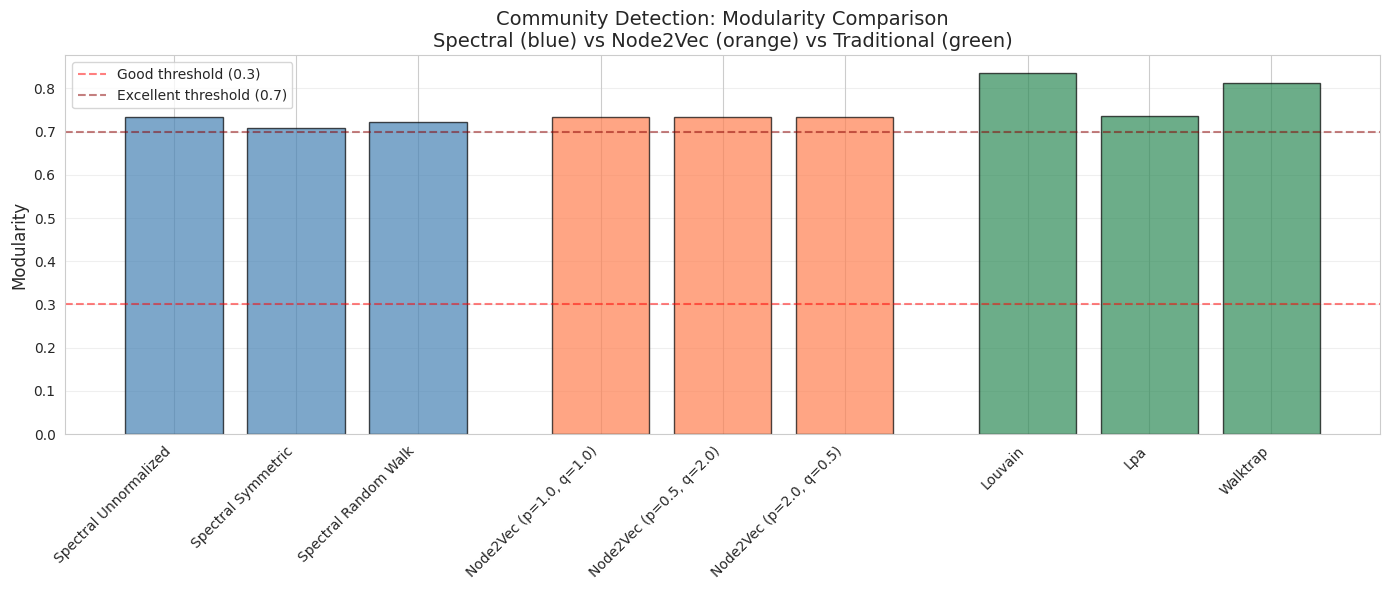


Best Modularity: Louvain (0.8347)


In [11]:
# Visualize Modularity Comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Group by category
categories = df_metrics['Category'].unique()
colors = {'Spectral': 'steelblue', 'Node2Vec': 'coral', 'Traditional': 'seagreen'}

x_pos = 0
x_positions = []
x_labels = []
bar_colors = []

for category in ['Spectral', 'Node2Vec', 'Traditional']:
    subset = df_metrics[df_metrics['Category'] == category]
    for _, row in subset.iterrows():
        x_positions.append(x_pos)
        x_labels.append(row['Method'])
        bar_colors.append(colors[category])
        x_pos += 1
    x_pos += 0.5  # Gap between categories

bars = ax.bar(x_positions, df_metrics['Modularity'], color=bar_colors, alpha=0.7, edgecolor='black')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel('Modularity', fontsize=12)
ax.set_title('Community Detection: Modularity Comparison\n' +
             'Spectral (blue) vs Node2Vec (orange) vs Traditional (green)', fontsize=14)
ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Good threshold (0.3)')
ax.axhline(y=0.7, color='darkred', linestyle='--', alpha=0.5, label='Excellent threshold (0.7)')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nBest Modularity: {df_metrics.loc[df_metrics['Modularity'].idxmax(), 'Method']} "
      f"({df_metrics['Modularity'].max():.4f})")

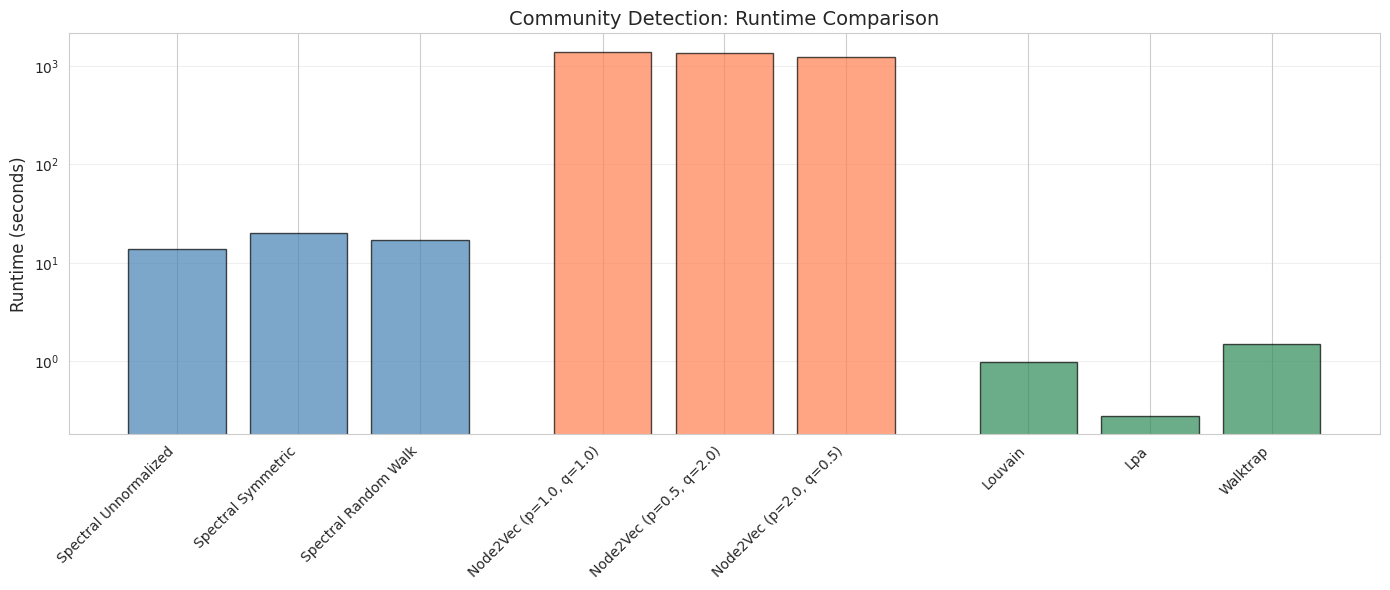


Fastest Method: Lpa (0.28s)


In [12]:
# Runtime Comparison
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(x_positions, df_metrics['Runtime (s)'], color=bar_colors, alpha=0.7, edgecolor='black')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Community Detection: Runtime Comparison', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nFastest Method: {df_metrics.loc[df_metrics['Runtime (s)'].idxmin(), 'Method']} "
      f"({df_metrics['Runtime (s)'].min():.2f}s)")

In [13]:
# Pairwise ARI and NMI comparison
print("\n" + "="*100)
print("PAIRWISE METHOD AGREEMENT (ARI / NMI)")
print("="*100)

# Collect all communities
all_communities = {}
for name, result in spectral_results.items():
    all_communities[name] = result['communities']
for name, result in node2vec_results.items():
    all_communities[name] = result['communities']
for name, result in traditional_results.items():
    all_communities[name] = result['communities']

method_names = list(all_communities.keys())

# Compute pairwise comparisons
comparison_data = []
for i, method1 in enumerate(method_names):
    for method2 in method_names[i+1:]:
        comm1 = all_communities[method1]
        comm2 = all_communities[method2]
        
        # Get common nodes
        common_nodes = sorted(set(comm1.keys()) & set(comm2.keys()))
        labels1 = np.array([comm1[node] for node in common_nodes])
        labels2 = np.array([comm2[node] for node in common_nodes])
        
        ari = adjusted_rand_score(labels1, labels2)
        nmi = normalized_mutual_info_score(labels1, labels2)
        
        comparison_data.append({
            'Method 1': method1,
            'Method 2': method2,
            'ARI': ari,
            'NMI': nmi
        })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.round(3).to_string(index=False))

print("\nInterpretation:")
print("  ARI/NMI close to 1.0 = high agreement")
print("  ARI/NMI close to 0.0 = low agreement")


PAIRWISE METHOD AGREEMENT (ARI / NMI)
             Method 1             Method 2   ARI   NMI
spectral_unnormalized   spectral_symmetric 0.860 0.932
spectral_unnormalized spectral_random_walk 0.916 0.938
spectral_unnormalized   node2vec_p1.0_q1.0 0.980 0.971
spectral_unnormalized   node2vec_p0.5_q2.0 0.980 0.970
spectral_unnormalized   node2vec_p2.0_q0.5 0.979 0.969
spectral_unnormalized              louvain 0.625 0.816
spectral_unnormalized                  lpa 0.870 0.864
spectral_unnormalized             walktrap 0.420 0.695
   spectral_symmetric spectral_random_walk 0.806 0.899
   spectral_symmetric   node2vec_p1.0_q1.0 0.854 0.928
   spectral_symmetric   node2vec_p0.5_q2.0 0.855 0.926
   spectral_symmetric   node2vec_p2.0_q0.5 0.854 0.926
   spectral_symmetric              louvain 0.561 0.806
   spectral_symmetric                  lpa 0.754 0.824
   spectral_symmetric             walktrap 0.344 0.662
 spectral_random_walk   node2vec_p1.0_q1.0 0.910 0.933
 spectral_random_walk   no

In [ ]:
# Visualize embeddings in 2D
def visualize_embeddings_2d(embeddings, communities_dict, method_name, nodes):
    """Project embeddings to 2D and visualize"""
    if embeddings.shape[1] > 2:
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)
        explained_var = pca.explained_variance_ratio_.sum()
    else:
        embeddings_2d = embeddings
        explained_var = 1.0
    
    labels = np.array([communities_dict[node] for node in nodes])
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='tab20', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    plt.colorbar(scatter, label='Community ID')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title(f'{method_name}\n2D Embedding Visualization ({explained_var:.1%} variance)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Visualizing Spectral Embeddings...



NameError: name 'spectral_results' is not defined

In [ ]:
# Visualize spectral embeddings
print("Visualizing Spectral Embeddings...\n")
for name, result in spectral_results.items():
    visualize_embeddings_2d(result['embeddings'], result['communities'],
                           name.replace('_', ' ').title(), list(G_fb.nodes()))

# Visualize Node2Vec embeddings
print("\nVisualizing Node2Vec Embeddings...\n")
for name, result in node2vec_results.items():
    visualize_embeddings_2d(result['embeddings'], result['communities'],
                           f"Node2Vec (p={result['p']}, q={result['q']})",
                           list(G_fb.nodes()))

## Part 5: Key Findings and Insights

### Comparison Summary

In [15]:
# Summary statistics by category
summary = df_metrics.groupby('Category').agg({
    'Modularity': ['mean', 'max', 'std'],
    'Runtime (s)': ['mean', 'min', 'max'],
    'Num Communities': ['mean', 'std']
}).round(4)

print("\n" + "="*70)
print("SUMMARY BY CATEGORY")
print("="*70)
print(summary)

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Best modularity
best_mod = df_metrics.loc[df_metrics['Modularity'].idxmax()]
print(f"\n1. BEST MODULARITY:")
print(f"   Method: {best_mod['Method']}")
print(f"   Score: {best_mod['Modularity']:.4f}")
print(f"   Category: {best_mod['Category']}")

# Fastest method
fastest = df_metrics.loc[df_metrics['Runtime (s)'].idxmin()]
print(f"\n2. FASTEST METHOD:")
print(f"   Method: {fastest['Method']}")
print(f"   Runtime: {fastest['Runtime (s)']:.2f}s")
print(f"   Category: {fastest['Category']}")

# Best balance (high modularity, low runtime)
df_metrics['Score'] = df_metrics['Modularity'] / (df_metrics['Runtime (s)'] + 1)
balanced = df_metrics.loc[df_metrics['Score'].idxmax()]
print(f"\n3. BEST BALANCE (Modularity/Runtime):")
print(f"   Method: {balanced['Method']}")
print(f"   Modularity: {balanced['Modularity']:.4f}")
print(f"   Runtime: {balanced['Runtime (s)']:.2f}s")

print("\n" + "="*70)


SUMMARY BY CATEGORY
            Modularity                 Runtime (s)                        \
                  mean     max     std        mean        min        max   
Category                                                                   
Node2Vec        0.7333  0.7334  0.0001   1328.6674  1238.1750  1398.4117   
Spectral        0.7213  0.7338  0.0129     17.1104    13.9526    20.2380   
Traditional     0.7945  0.8347  0.0512      0.9178     0.2789     1.4841   

            Num Communities           
                       mean      std  
Category                              
Node2Vec             7.0000   0.0000  
Spectral             7.0000   0.0000  
Traditional         45.3333  31.0215  

KEY INSIGHTS

1. BEST MODULARITY:
   Method: Louvain
   Score: 0.8347
   Category: Traditional

2. FASTEST METHOD:
   Method: Lpa
   Runtime: 0.28s
   Category: Traditional

3. BEST BALANCE (Modularity/Runtime):
   Method: Lpa
   Modularity: 0.7368
   Runtime: 0.28s



In [ ]:
## UNCOMMENT IF RESULTS NEED TO BE SAVED

# # Save all results
# print("Saving results...\n")

# df_metrics.to_csv('embedding_methods_full_comparison.csv', index=False)
# print("✓ Saved: embedding_methods_full_comparison.csv")

# df_comparison.to_csv('pairwise_method_agreement.csv', index=False)
# print("✓ Saved: pairwise_method_agreement.csv")

# summary.to_csv('category_summary_statistics.csv')
# print("✓ Saved: category_summary_statistics.csv")

# print("\nAll results saved successfully!")

## Part 6: Graph Neural Networks (GNN) for Community Detection

In this section, we apply a simple Graph Neural Network (GNN) approach for community detection using the PyTorch Geometric library. GNNs can learn node embeddings by aggregating information from neighbors, which can then be clustered to reveal communities.

**Pipeline:**
1. Convert the NetworkX graph to PyTorch Geometric format
2. Define a simple Graph Convolutional Network (GCN)
3. Train the GCN to learn node embeddings (unsupervised)
4. Cluster the embeddings using k-means
5. Evaluate and compare with previous methods

**Note:** This requires `torch` and `torch_geometric` libraries.

In [13]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
from sklearn.cluster import KMeans

# Convert NetworkX graph to PyTorch Geometric Data object
G_fb_pg = G_fb.copy()
for n in G_fb_pg.nodes():
    G_fb_pg.nodes[n]['feat'] = [1.0]  # Dummy feature

data = from_networkx(G_fb_pg)
data.x = torch.tensor([G_fb_pg.nodes[n]['feat'] for n in G_fb_pg.nodes()], dtype=torch.float)

In [4]:
# Define a simple 2-layer GCN for unsupervised embedding
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


In [5]:
# Train GCN (unsupervised, using reconstruction loss)
def train_gcn_unsupervised(data, n_clusters, epochs=50, hidden_dim=32, embed_dim=16, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GCNEncoder(data.x.shape[1], hidden_dim, embed_dim).to(device)
    data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        # Inner product decoder (reconstruction)
        adj_pred = torch.sigmoid(torch.matmul(z, z.t()))
        adj_true = torch.zeros_like(adj_pred)
        adj_true[data.edge_index[0], data.edge_index[1]] = 1.0
        loss = F.binary_cross_entropy(adj_pred, adj_true)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")
    model.eval()
    with torch.no_grad():
        embeddings = model(data.x, data.edge_index).cpu().numpy()
    # Cluster embeddings
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    communities = {int(n): int(labels[i]) for i, n in enumerate(G_fb.nodes())}
    return communities, embeddings, model

In [7]:
k_opt=7

In [8]:
# Run GNN community detection
print("\nRunning GNN (GCN) Community Detection...\n")
gnn_communities, gnn_embeddings, gnn_model = train_gcn_unsupervised(data, n_clusters=k_opt, epochs=50)
print(f"GNN detected {len(set(gnn_communities.values()))} communities.")


Running GNN (GCN) Community Detection...

Epoch 10/50 - Loss: 0.7221
Epoch 20/50 - Loss: 0.7052
Epoch 30/50 - Loss: 0.6956
Epoch 40/50 - Loss: 0.6949
Epoch 50/50 - Loss: 0.6934
GNN detected 7 communities.


In [13]:
# Evaluate GNN communities
print("\nEvaluating GNN communities...\n")
gnn_metrics = evaluate_communities(G_fb, gnn_communities, 'GNN (GCN)')
gnn_metrics['Runtime (s)'] = None  # Not tracked separately
gnn_metrics['Category'] = 'GNN'

# Display metrics as a DataFrame for nicer formatting
gnn_df = pd.DataFrame([gnn_metrics]).round(4)
from IPython.display import display
display(gnn_df)



Evaluating GNN communities...



,Method,Modularity,Coverage,Avg Conductance,Num Communities,Avg Size,Max Size,Min Size,Runtime (s),Category
0,GNN (GCN),0.0488,0.3401,0.8232,7,577.0,1161,5,None,GNN



Visualizing GNN Embeddings...



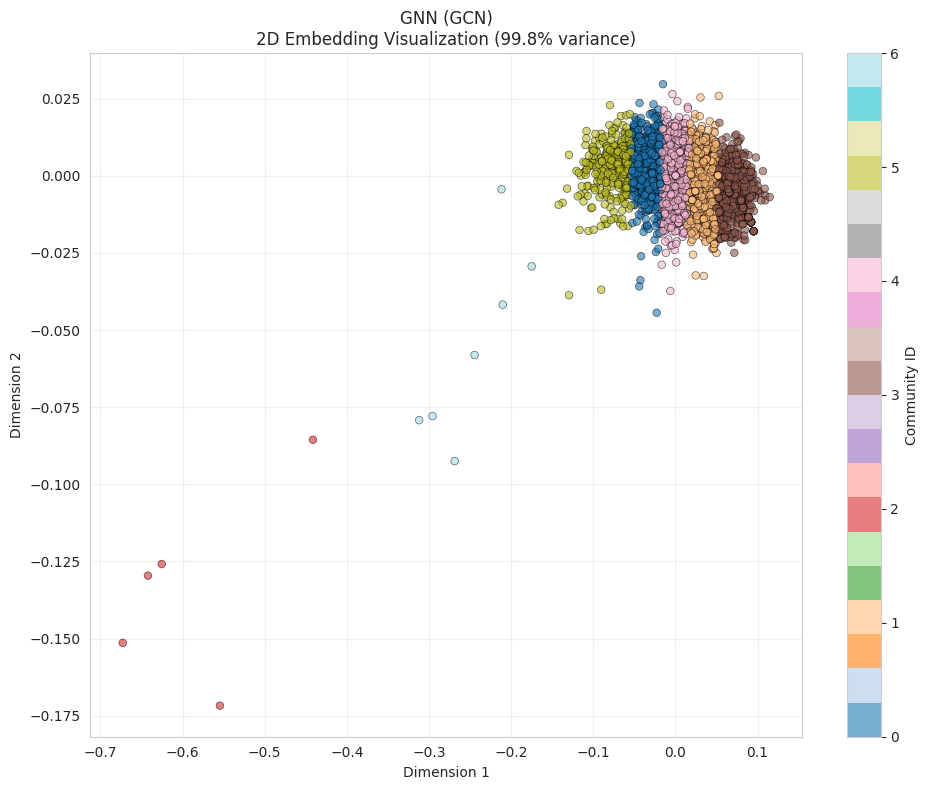

In [16]:
# Visualize GNN embeddings
print("\nVisualizing GNN Embeddings...\n")
visualize_embeddings_2d(gnn_embeddings, gnn_communities, 'GNN (GCN)', list(G_fb.nodes()))

## Part 7: Link Prediction using GCN

We implement **link prediction**: given the graph structure and node features, we train a GCN to predict, for each candidate pair of nodes, whether an edge exists. The model is a 2-layer GCN encoder plus a decoder that outputs a **score/logit** for each pair; applying a sigmoid gives the probability for the link.

**Pipeline (link prediction):**  
1. Build data add node features (degree, clustering coefficient, PageRank)  
2. Create train/val/test splits(with negative samples) using `RandomLinkSplit` 
3. Define 2-layer `GCNConv` encoder and an MLP decoder o  
4. Train and Optimise BCE loss over positive and negative training pairs   
5. Evaluate on held-out validation and test edges, compute AUC-ROC, Average Precision, Accuracy (via thresholding probabilities), and ranking metrics (MRR, HITS@k) 


In [ ]:
# Link Prediction with GCN
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
import random

# 1. Build PyG Data from Facebook graph with richer node features (degree, clustering, PageRank)
G_lp = G_fb.copy()
node_list = list(G_lp.nodes())
degs = np.array([G_lp.degree(n) for n in node_list], dtype=float)
deg_max = max(degs.max(), 1.0)
degs_norm = degs / deg_max
clustering = nx.clustering(G_lp)
clust = np.array([clustering[n] for n in node_list], dtype=float)
clust_max = max(clust.max(), 1e-10)
clust_norm = clust / clust_max
pr = nx.pagerank(G_lp)
pagerank_vals = np.array([pr[n] for n in node_list], dtype=float)
pr_max = max(pagerank_vals.max(), 1e-10)
pr_norm = pagerank_vals / pr_max

for i, n in enumerate(node_list):
    G_lp.nodes[n]['feat'] = [float(degs_norm[i]), float(clust_norm[i]), float(pr_norm[i])]
data_lp = from_networkx(G_lp)
data_lp.x = torch.tensor([G_lp.nodes[n]['feat'] for n in node_list], dtype=torch.float)

# 2. Train/val/test split (RandomLinkSplit)
transform = RandomLinkSplit(num_val=0.05, num_test=0.10, is_undirected=True, add_negative_train_samples=True, split_labels=False, disjoint_train_ratio=0.0)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
train_data, val_data, test_data = transform(data_lp)

print("Link prediction data prepared:")
print(f"  Nodes: {train_data.num_nodes}, Features: {train_data.x.shape[1]}")
print(f"  Train message-passing edges: {train_data.edge_index.shape[1]}")
print(f"  Train edge labels (pos+neg): {train_data.edge_label_index.shape[1]} (pos: {int(train_data.edge_label.sum().item())})")
print(f"  Val edge pairs: {val_data.edge_label_index.shape[1]} (pos: {int(val_data.edge_label.sum().item())})")
print(f"  Test edge pairs: {test_data.edge_label_index.shape[1]} (pos: {int(test_data.edge_label.sum().item())})")

# 3. Verify no overlap between train / val / test
def pairs_as_set(edge_label_index):
    e = edge_label_index.cpu().numpy()
    return set(zip(e[0].tolist(), e[1].tolist()))
train_pairs = pairs_as_set(train_data.edge_label_index)
val_pairs = pairs_as_set(val_data.edge_label_index)
test_pairs = pairs_as_set(test_data.edge_label_index)
assert len(train_pairs & val_pairs) == 0 and len(train_pairs & test_pairs) == 0 and len(val_pairs & test_pairs) == 0, "Overlap in splits"
print("  No overlap between train / val / test (verified).")


Link prediction data prepared:
  Nodes: 4039, Features: 3
  Train message-passing edges: 150000
  Train edge labels (pos+neg): 150000 (pos: 75000)
  Val edge pairs: 8822 (pos: 4411)
  Test edge pairs: 17646 (pos: 8823)
  No overlap between train / val / test (verified).




- **Node features** – The Facebook dataset has no user attributes, only the edge list. We build a 3-D feature vector per node from **degree**, **clustering coefficient**, and **PageRank**, each normalized by its maximum so values are on a similar scale. In practice this gives better link-prediction performance than using a single constant for all nodes, because the GCN can use both local structure (clustering) and global importance (PageRank) together with degree.  

- **Train / val / test split** – RandomLinkSplit produces three datasets. Each has **edge_index** (the edges used for message passing) and **edge_label_index** / **edge_label** (the node pairs we predict and their labels: 1 = link, 0 = no link). We use 5% of edges for validation and 10% for test; the rest (with added negative samples) form the training set.  

- **No overlap** – We fix the random seed for reproducibility and explicitly check that no (src, dst) pair appears in more than one split. That avoids data leakage and keeps validation and test metrics meaningful.  


**Observation** – With 3 features we get 4039 nodes and 3 feature dimensions. The training set has 150k edge labels (half positive, half negative); val and test have 8822 and 17646 pairs each, respectively, with no overlap between splits.

### GCN Encoder and Link Decoder

- **Encoder**: A 2-layer GCN: each layer aggregates features over the node and its neighbours with degree-based scaling $1/\sqrt{d_i d_j}$. PyG's `GCNConv` implements this. The first layer uses ReLU and dropout; the second has no activation so we get raw embeddings for the decoder.  
- **Decoder**: We use an **MLP** that takes the concatenation of the two node embeddings $[z_u \| z_v]$ and outputs a single logit per pair. Alternatively we could use the dot product $z_u^T z_v$; the MLP gives a more flexible scoring function and in our runs it reaches higher AUC/AP after enough epochs.

In [ ]:
# GCN Encoder for link prediction 
class GCNLinkEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Layer 1: message passing + ReLU
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        # Layer 2: no activation so embeddings stay in R^d for dot product
        x = self.conv2(x, edge_index)
        return x


# Decoder: link score from node embeddings
def decode_link_dot(z, edge_label_index):
    """Dot product decoder: hat{y}_{uv} = z_u^T z_v (then we apply sigmoid for BCE)."""
    src, dst = edge_label_index[0], edge_label_index[1]
    logits = (z[src] * z[dst]).sum(dim=-1)
    return logits


# MLP decoder: score from concatenation [z_u || z_v]
class LinkMLPDecoder(nn.Module):
    def __init__(self, out_channels, hidden_mlp=64):
        super().__init__()
        # Input: concatenation of z_u and z_v -> shape (num_pairs, 2*out_channels)
        self.mlp = nn.Sequential(
            nn.Linear(2 * out_channels, hidden_mlp),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_mlp, 1),
        )

    def forward(self, z, edge_label_index):
        src, dst = edge_label_index[0], edge_label_index[1]
        z_pair = torch.cat([z[src], z[dst]], dim=-1)  # (num_pairs, 2*out_channels)
        logits = self.mlp(z_pair).squeeze(-1)
        return logits


# Full model: encoder + decoder (MLP by default)
class GCNLinkPrediction(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_mlp_decoder=True):
        super().__init__()
        self.encoder = GCNLinkEncoder(in_channels, hidden_channels, out_channels)
        self.use_mlp_decoder = use_mlp_decoder
        if use_mlp_decoder:
            self.decoder = LinkMLPDecoder(out_channels)
        else:
            self.decoder = None

    def forward(self, x, edge_index, edge_label_index):
        z = self.encoder(x, edge_index)
        if self.decoder is not None:
            logits = self.decoder(z, edge_label_index)
        else:
            logits = decode_link_dot(z, edge_label_index)
        return logits


- **GCNLinkEncoder**: Two `GCNConv` layers (message passing + ReLU + dropout, then a second layer with no activation) so we get embedding vectors we can feed to the decoder.  
- **LinkMLPDecoder**: For each pair (u, v) we concatenate their embeddings $[z_u \| z_v]$ and pass them through a small MLP (linear → ReLU → dropout → linear) to get one logit per pair. This lets the model learn a more flexible link score than the dot product.  
- **GCNLinkPrediction**: Encoder plus decoder. We use the MLP decoder by default; set `use_mlp_decoder=False` to use the dot-product decoder instead.  

**Why** – The GCN aggregates neighbourhood information into node embeddings; the MLP then learns how to combine two embeddings into a link score. Outputs are logits (no sigmoid in the model) so we can use BCE with logits for training. In our runs the MLP decoder typically reaches higher validation AUC/AP than the dot product after enough epochs.

### Training Loop – Binary Cross-Entropy

We minimise BCE loss over all training pairs (positive and negative). Labels are in `train_data.edge_label`. The model outputs **logits** for each pair and applies the sigmoid internally in a numerically stable way.

At prediction time we:
- Apply `torch.sigmoid(logits)` to get **probabilities** in \([0,1]\).
- For **binary prediction** (edge / no edge), threshold the probability (e.g., 0.5) to decide whether we predict a link; this is what we use for **accuracy**.
- For **ranking metrics** (MRR, HITS@k), we **do not threshold**: we use the raw probabilities/scores to **rank** pairs and then compute the rank of each true edge among many negatives. This is what lets us measure how well the model orders likely vs unlikely links.

In [ ]:
# Training and evaluation (weight decay, scheduler, early stopping)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_dim = train_data.x.shape[1]
hidden_dim = 128
out_dim = 64
model = GCNLinkPrediction(in_dim, hidden_dim, out_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

def train_link_prediction(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    labels = data.edge_label.float()
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return float(loss)

def _compute_mrr_hits(probs, labels, k_list=(1, 3, 10, 50)):
    pos_mask = labels == 1
    neg_mask = labels == 0
    pos_probs = probs[pos_mask]
    neg_probs = probs[neg_mask]
    if len(pos_probs) == 0:
        return 0.0, {k: 0.0 for k in k_list}
    ranks = 1 + (neg_probs.reshape(1, -1) > pos_probs.reshape(-1, 1)).sum(axis=1).astype(float)
    mrr = np.mean(1.0 / ranks)
    hits = {k: np.mean((ranks <= k).astype(float)) for k in k_list}
    return mrr, hits

@torch.no_grad()
def evaluate_link_prediction(model, data, k_list=(1, 3, 10, 50)):
    model.eval()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    probs = torch.sigmoid(logits).cpu().numpy()
    labels = data.edge_label.cpu().numpy()
    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)
    pred = (probs >= 0.5).astype(float)
    acc = accuracy_score(labels, pred)
    mrr, hits = _compute_mrr_hits(probs, labels, k_list=k_list)
    return auc, ap, acc, mrr, hits

# Train with early stopping; track best by val AUC and by val MRR (for comparison)
epochs = 500
patience = 60
best_val_auc = 0.0
best_state = None
best_val_mrr = 0.0
best_state_mrr = None
for epoch in range(1, epochs + 1):
    loss = train_link_prediction(model, train_data, optimizer)
    val_auc, val_ap, val_acc, val_mrr, val_hits = evaluate_link_prediction(model, val_data)
    scheduler.step(val_auc)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    if val_mrr > best_val_mrr:
        best_val_mrr = val_mrr
        best_state_mrr = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Loss: {loss:.4f}  Val AUC: {val_auc:.4f}  AP: {val_ap:.4f}  Acc: {val_acc:.4f}  MRR: {val_mrr:.4f}  HITS@10: {val_hits[10]:.4f}")
    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
        break
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print("Restored best model (by val AUC) for test evaluation.")


Epoch  20  Loss: 0.5443  Val AUC: 0.8025  AP: 0.8173  Acc: 0.7222  MRR: 0.0308  HITS@10: 0.0401
Epoch  40  Loss: 0.5091  Val AUC: 0.8262  AP: 0.8373  Acc: 0.7518  MRR: 0.0294  HITS@10: 0.0415
Epoch  60  Loss: 0.4274  Val AUC: 0.9049  AP: 0.9055  Acc: 0.8206  MRR: 0.0520  HITS@10: 0.1587
Epoch  80  Loss: 0.3356  Val AUC: 0.9337  AP: 0.9268  Acc: 0.8560  MRR: 0.0444  HITS@10: 0.0451
Epoch 100  Loss: 0.3162  Val AUC: 0.9375  AP: 0.9311  Acc: 0.8607  MRR: 0.0437  HITS@10: 0.0914
Epoch 120  Loss: 0.3062  Val AUC: 0.9393  AP: 0.9326  Acc: 0.8633  MRR: 0.0449  HITS@10: 0.1168
Epoch 140  Loss: 0.2998  Val AUC: 0.9409  AP: 0.9345  Acc: 0.8665  MRR: 0.0452  HITS@10: 0.0911
Epoch 160  Loss: 0.2975  Val AUC: 0.9422  AP: 0.9360  Acc: 0.8687  MRR: 0.0460  HITS@10: 0.1050
Epoch 180  Loss: 0.2973  Val AUC: 0.9427  AP: 0.9368  Acc: 0.8702  MRR: 0.0474  HITS@10: 0.1106
Epoch 200  Loss: 0.2930  Val AUC: 0.9435  AP: 0.9382  Acc: 0.8700  MRR: 0.0511  HITS@10: 0.1233
Epoch 220  Loss: 0.2880  Val AUC: 0.9449


- **Setup**: Model (hidden 128, out 64) and data on device; Adam with weight decay 5e-4. Each training step: forward on the training graph and training pairs, BCE loss, backward, **gradient clipping** (max_norm=1.0) to avoid exploding gradients, then optimizer step.  
- **Evaluation**: We compute AUC-ROC, AP, accuracy (threshold 0.5), MRR, and HITS@k on validation each epoch.  
- **ReduceLROnPlateau**: If validation AUC does not improve for 30 epochs, the learning rate is halved.  
- **Early stopping**: We save the best model state (by validation AUC). If there is no improvement for 60 epochs we stop and **restore the best model** before running test evaluation.  

**Why** – Adam adapts the step size per parameter and usually converges well with little tuning. Weight decay and the scheduler help generalization; early stopping avoids overfitting and ensures we report test metrics for the best checkpoint, not the last epoch. Gradient clipping stabilizes training with the MLP decoder.  

**Observation** – Validation AUC/AP tend to improve over time. MRR and HITS@10 often fluctuate from epoch to epoch because they depend on exact ranks: small score changes can swap the rank of a positive (e.g. from 2nd to 4th). We therefore use validation AUC to choose the best checkpoint; the final test metrics are reported for that checkpoint.

### Test Set Evaluation

We score the held-out test pairs with the best model (restored by validation AUC) and report:  
- **AUC-ROC**, **Average Precision (AP)**, **Accuracy** (threshold 0.5)  
- **MRR**: For each positive pair we rank its score only against the negatives (per-positive ranking). Rank = 1 + (number of negatives with higher score). MRR = mean of 1/rank over positives (max 1.0).  
- **HITS@k**: Fraction of positive pairs with rank ≤ k (e.g. HITS@1 = fraction of positives ranked first).

In [ ]:
# Test evaluation: best checkpoint by val AUC (current model)
test_auc, test_ap, test_acc, test_mrr, test_hits = evaluate_link_prediction(model, test_data)
print("Link Prediction (GCN) – Test results [best by val AUC]:")
print(f"  AUC-ROC:      {test_auc:.4f}")
print(f"  Avg Precision: {test_ap:.4f}")
print(f"  Accuracy (0.5): {test_acc:.4f}")
print(f"  MRR:          {test_mrr:.4f}")
print(f"  HITS@1:       {test_hits[1]:.4f}")
print(f"  HITS@3:       {test_hits[3]:.4f}")
print(f"  HITS@10:      {test_hits[10]:.4f}")
print(f"  HITS@50:      {test_hits[50]:.4f}")

Link Prediction (GCN) – Test set results:
  AUC-ROC:      0.9679
  Avg Precision: 0.9684
  Accuracy (0.5): 0.9051
  MRR:          0.2186
  HITS@1:       0.1584
  HITS@3:       0.2310
  HITS@10:      0.3085
  HITS@50:      0.5096


**Interpretation in relation to the graph**  

The Facebook graph is a social network of friendships: nodes are users, edges are "friend" links. Link prediction here answers: given the current graph, which **missing** edges (user pairs not yet connected) are most likely to become friendships?  

- **High AUC-ROC / AP** (e.g. mid‑0.90s) means the model ranks true held-out edges higher than random non-edges most of the time. That implies friendship in this network is **partly predictable** from structure and from our node features (degree, clustering, PageRank): well-connected or central nodes, and pairs with many common neighbours (captured by the GCN), tend to be linked.  

- **MRR and HITS@k** measure how well we rank the *true* link among many negatives. Lower MRR/HITS@10 than AUC is normal: we have one positive per "query" and many negatives, so getting the true link in the top 10 is harder than simply beating a random classifier. The values we see suggest that for a sizeable fraction of test edges, the model places the true link in a reasonably high position; the rest are harder (e.g. weak structural signal or ambiguous pairs).  

- **What it implies**: The graph has enough local and global structure (neighbourhood overlap, centrality) that a GCN with simple node statistics can learn a useful scoring function. Choosing the checkpoint by **val AUC** vs **val MRR** (see the two result blocks above) shows whether optimizing for overall ranking (AUC) vs for "true link in top-k" (MRR) changes which epoch we pick and how test MRR/HITS look.  

**Reflection** – When reporting results, it is useful to give both AUC/AP (overall discriminative ability) and MRR/HITS@k (quality of the ranked shortlist). If the task is "recommend top-10 likely new friends," HITS@10 is more directly relevant; if the task is "score all pairs for downstream use," AUC and AP matter more. The fact that we can predict a substantial fraction of missing links from structure alone is a takeaway for both analysis and design of recommendation or anomaly-detection systems.

---
## Part 8: Link Prediction on Email-Eu-core Dataset

We run the **same GCN link-prediction pipeline** (Part 7) on the **Email-Eu-core** network to compare performance across datasets. The pipeline is unchanged: **richer node features** (degree, clustering, PageRank), RandomLinkSplit, 2-layer GCN encoder, MLP decoder, BCE loss, and evaluation with AUC, AP, MRR, and HITS@k.

In [85]:
# Part 8: Link prediction on Email-Eu-core (same pipeline as Part 7, step by step)
G_email = nx.read_edgelist('data/email-Eu-core.txt', create_using=nx.Graph(), nodetype=int)
print(f"Email-Eu-core: nodes={G_email.number_of_nodes()}, edges={G_email.number_of_edges()}, density={nx.density(G_email):.4f}")

# 1. Richer node features (degree, clustering, PageRank) – same as Part 7
G_email_lp = G_email.copy()
node_list_em = list(G_email_lp.nodes())
degs_em = np.array([G_email_lp.degree(n) for n in node_list_em], dtype=float)
deg_max_em = max(degs_em.max(), 1.0)
degs_norm_em = degs_em / deg_max_em
clustering_em = nx.clustering(G_email_lp)
clust_em = np.array([clustering_em[n] for n in node_list_em], dtype=float)
clust_max_em = max(clust_em.max(), 1e-10)
clust_norm_em = clust_em / clust_max_em
pr_em = nx.pagerank(G_email_lp)
pr_vals_em = np.array([pr_em[n] for n in node_list_em], dtype=float)
pr_max_em = max(pr_vals_em.max(), 1e-10)
pr_norm_em = pr_vals_em / pr_max_em
for i, n in enumerate(node_list_em):
    G_email_lp.nodes[n]['feat'] = [float(degs_norm_em[i]), float(clust_norm_em[i]), float(pr_norm_em[i])]
data_email = from_networkx(G_email_lp)
data_email.x = torch.tensor([G_email_lp.nodes[n]['feat'] for n in node_list_em], dtype=torch.float)

# 2. Train/val/test split (same transform params and seeds)
transform_em = RandomLinkSplit(num_val=0.05, num_test=0.10, is_undirected=True, add_negative_train_samples=True, split_labels=False, disjoint_train_ratio=0.0)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
train_em, val_em, test_em = transform_em(data_email)
train_em = train_em.to(device)
val_em = val_em.to(device)
test_em = test_em.to(device)

# 3. Model and training 
in_dim_em = train_em.x.shape[1]
model_em = GCNLinkPrediction(in_dim_em, 128, 64).to(device)
opt_em = torch.optim.AdamW(model_em.parameters(), lr=0.01, weight_decay=5e-4)
scheduler_em = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_em, mode='max', factor=0.5, patience=30)
epochs_em = 500
patience_em = 60
best_val_auc_em = 0.0
best_state_em = None
no_improve_em = 0
for epoch in range(1, epochs_em + 1):
    loss_em = train_link_prediction(model_em, train_em, opt_em)
    va, vp, vac, vm, vh = evaluate_link_prediction(model_em, val_em)
    scheduler_em.step(va)
    if va > best_val_auc_em:
        best_val_auc_em = va
        best_state_em = {k: v.cpu().clone() for k, v in model_em.state_dict().items()}
        no_improve_em = 0
    else:
        no_improve_em += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Loss: {loss_em:.4f}  Val AUC: {va:.4f}  AP: {vp:.4f}  Acc: {vac:.4f}  MRR: {vm:.4f}  HITS@10: {vh[10]:.4f}")
    if no_improve_em >= patience_em:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience_em} epochs).")
        break
if best_state_em is not None:
    model_em.load_state_dict(best_state_em)
    model_em = model_em.to(device)
    print("Restored best model (by val AUC) for test evaluation.")

# 4. Test evaluation
ta, tp, tac, tm, th = evaluate_link_prediction(model_em, test_em)
print("\nLink Prediction (GCN) on Email-Eu-core – Test results:")
print(f"  AUC-ROC:      {ta:.4f}")
print(f"  Avg Precision: {tp:.4f}")
print(f"  Accuracy:     {tac:.4f}")
print(f"  MRR:          {tm:.4f}")
print(f"  HITS@1:       {th[1]:.4f}  HITS@3: {th[3]:.4f}  HITS@10: {th[10]:.4f}  HITS@50: {th[50]:.4f}")

Email-Eu-core: nodes=1005, edges=16706, density=0.0331
Epoch  20  Loss: 0.4885  Val AUC: 0.8730  AP: 0.8692  Acc: 0.7814  MRR: 0.1095  HITS@10: 0.2599
Epoch  40  Loss: 0.4512  Val AUC: 0.8806  AP: 0.8739  Acc: 0.7958  MRR: 0.1073  HITS@10: 0.2371
Epoch  60  Loss: 0.4422  Val AUC: 0.8830  AP: 0.8758  Acc: 0.7892  MRR: 0.1062  HITS@10: 0.2539
Epoch  80  Loss: 0.4450  Val AUC: 0.8833  AP: 0.8761  Acc: 0.7964  MRR: 0.1074  HITS@10: 0.2635
Epoch 100  Loss: 0.4394  Val AUC: 0.8841  AP: 0.8766  Acc: 0.7928  MRR: 0.1073  HITS@10: 0.2683
Epoch 120  Loss: 0.4370  Val AUC: 0.8843  AP: 0.8768  Acc: 0.7958  MRR: 0.1071  HITS@10: 0.2695
Epoch 140  Loss: 0.4351  Val AUC: 0.8848  AP: 0.8771  Acc: 0.7958  MRR: 0.1075  HITS@10: 0.2659
Epoch 160  Loss: 0.4330  Val AUC: 0.8866  AP: 0.8792  Acc: 0.7994  MRR: 0.1086  HITS@10: 0.2671
Epoch 180  Loss: 0.4211  Val AUC: 0.8926  AP: 0.8866  Acc: 0.7994  MRR: 0.1170  HITS@10: 0.2934
Epoch 200  Loss: 0.4233  Val AUC: 0.8984  AP: 0.8927  Acc: 0.8144  MRR: 0.1241  H

**Interpretation in relation to the Email-Eu-core graph**  

The Email-Eu-core network represents email exchanges between members of a European research institution: nodes are email addresses (or people), edges indicate that at least one email was sent between the pair. The graph is smaller (about 1005 nodes) and denser (density ~0.033) than the Facebook graph, so average degree is higher and the structure is different.  

- **AUC-ROC and AP** in the high 0.80s–0.90s indicate that the same GCN pipeline (degree, clustering, PageRank + MLP decoder) also learns a useful link score here: true email links are generally ranked above random non-links. Communication in this network is partly predictable from who is already connected and from centrality. That is useful when building contact-recommendation or studying how communication networks form.  

- **MRR and HITS@k** are often slightly lower than on Facebook for comparable AUC, which can reflect the smaller test set (more variance), a different distribution of “easy” vs “hard” pairs, or the fact that email links may depend more on external factors (e.g. projects, departments) that we do not encode as features.  

- **Comparison with Part 7 (Facebook)**: Using the same pipeline on both graphs shows that the approach generalizes without dataset-specific tuning. Lower test AUC/MRR on Email in many runs reflects graph size, density, and how much link structure is explained by our three node statistics. For a fair comparison, report the same metrics and split strategy so differences can be attributed to the graph rather than the evaluation setup.  

**Reflection** – Reusing the same features and model across datasets makes the comparison interpretable when writing up results. To improve Email further, we could add domain-specific signals (e.g. department or role, if available) or tune hyperparameters (epochs, patience) for the smaller graph. The current results show that structural features alone carry substantial signal for link prediction in both social and communication networks.

### Discussion

**Community detection (Parts 1–6)**  

- Multiple community detection methods were evaluated: Spectral Clustering, Node2Vec, Traditional algorithms (Louvain, LPA, Walktrap), and Graph Neural Networks (GCN).
- Spectral Clustering leverages the eigenvalues of Laplacian matrices to reveal community structure, with the eigengap heuristic guiding the optimal number of clusters. It generally produces well-separated communities and good modularity scores.
- Node2Vec uses biased random walks and word embedding techniques to capture both local and global graph structure. Different parameter settings allow for flexible exploration.
- Traditional methods like Louvain, Label Propagation, and Walktrap are fast and scalable, often serving as baselines. Louvain typically achieves high modularity, which in fact, got the highest among all the community detection methods at 83.47%. Walktrap follows at 81.19%. Spectral Clustering, Node2Vec and GCN gave moderate performance.


**Link prediction (Parts 7–8)**  
- We implemented link prediction with a 2-layer GCN encoder and an MLP decoder on the concatenated node embeddings. Node features are degree, clustering coefficient, and PageRank (no raw attributes). We use RandomLinkSplit for train/val/test, BCE loss, weight decay, a learning-rate scheduler, and early stopping; we also track the best checkpoint by validation AUC and by validation MRR so we can compare test results for both criteria.  
- On the **Facebook** graph we obtain high test AUC and AP (e.g. mid‑0.90s), with MRR and HITS@k in a lower but interpretable range; the graph has enough structure that missing links are partly predictable from neighbourhood and centrality. On **Email-Eu-core** we run the same pipeline without tuning; test AUC/AP are typically in the high 0.80s–0.90s, with slightly lower MRR/HITS than on Facebook, reflecting the smaller graph and different link structure. The comparison shows that the approach generalizes across social and communication networks.  

- Future work could explore advanced GNN architectures, more node features or attributes, and other link-prediction decoders or evaluation setups.